In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

In [16]:
df=pd.read_csv('../Data/datamain.csv')
print(df.head())
print(df.columns)

   skill_match_score  experience_match_score  semantic_similarity_score  \
0               0.17                    0.62                     0.5825   
1               0.00                    1.00                     0.6030   
2               0.00                    1.00                     0.4904   
3               0.00                    1.00                     0.4277   
4               0.00                    1.00                     0.5142   

   domain_match  education_match_score    match_label  num_match_label  
0             1                   0.55  partial match              0.5  
1             0                   0.27       no match              0.0  
2             0                   0.46  partial match              0.5  
3             0                   0.09       no match              0.0  
4             0                   0.66  partial match              0.5  
Index(['skill_match_score', 'experience_match_score',
       'semantic_similarity_score', 'domain_match', 'educ

LOGISTIC REGRESSION ANALYSIS FOR MATCH LABEL

In [17]:
# Select features and target
# -----------------------------
X = df[['skill_match_score', 'experience_match_score','semantic_similarity_score','domain_match']]   
y = df['match_label']                               

# -----------------------------
# Split the dataset
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# Scale the features
# -----------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Create and train the model
# -----------------------------
model = LogisticRegression()

model.fit(X_train, y_train)

# -----------------------------
# Model parameters
# -----------------------------
print("Weights:", model.coef_)
print("Bias:", model.intercept_)

# -----------------------------
# Predictions
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# # -----------------------------
# # Predict on new data
# # -----------------------------
# new_data = [[, value2, value3]]   # Replace with actual values

# # Scale using the same scaler
# new_data = scaler.transform(new_data)

# prediction = model.predict(new_data)
# probability = model.predict_proba(new_data)

# print("\nPrediction:", prediction[0])
# print("Probabilities:", probability)

Weights: [[ 0.693792   -0.01843661  0.91422564  0.34393923]
 [-0.73471877  0.03329828 -0.95775231 -0.11718629]
 [ 0.04092677 -0.01486167  0.04352667 -0.22675294]]
Bias: [-0.38758778  0.02185495  0.36573284]
Accuracy: 0.67

Confusion Matrix:
[[22  1  4]
 [ 0 34  4]
 [ 9 15 11]]

Classification Report:
               precision    recall  f1-score   support

        match       0.71      0.81      0.76        27
     no match       0.68      0.89      0.77        38
partial match       0.58      0.31      0.41        35

     accuracy                           0.67       100
    macro avg       0.66      0.67      0.65       100
 weighted avg       0.65      0.67      0.64       100



DIMENSIONALITY ANALYSIS ON 2-D TO VERIFY LACK OF PERFORMANCE OF LOG-REG (for PARTIAL MATCH OUTPUT)

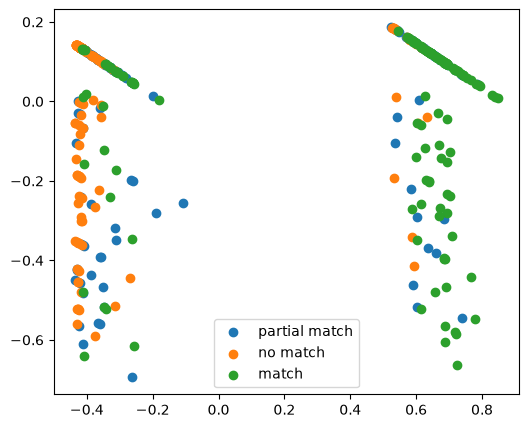

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.figure(figsize=(6,5))
for label in y.unique():
    idx = (y == label)
    plt.scatter(X_pca[idx,0], X_pca[idx,1], label=label)
plt.legend()
plt.show()

RANDOM FOREST CLASSIFIER [NON LINEAR CLASSIFICATION]

In [19]:
df=pd.read_csv('../Data/datamain.csv')
# Features and target
X = df.drop(["match_label",'num_match_label'], axis=1)
y = df["match_label"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred = rf_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.00

Confusion Matrix:
[[32  0  0]
 [ 0 38  0]
 [ 0  0 30]]

Classification Report:
               precision    recall  f1-score   support

        match       1.00      1.00      1.00        32
     no match       1.00      1.00      1.00        38
partial match       1.00      1.00      1.00        30

     accuracy                           1.00       100
    macro avg       1.00      1.00      1.00       100
 weighted avg       1.00      1.00      1.00       100

